# SHO Fitting

This notebook completes the SHO fitting using the conventional algorithms in Pycroscopy. 

## Import Packages

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")
sys.path.append('../../src')
sys.path.append('/home/julian/BEPiezo-Learn/src')

In [2]:
# # For the notebook to work you must have m3_learning installed
# # pip install m3_learning
%load_ext autoreload
%autoreload 2

from m3util.viz.printing import printer
from m3util.viz.style import set_style
from m3util.ml.rand import set_seeds
from m3util.util.IO import download_and_unzip
from belearn.dataset.dataset_new import BE_Dataset
from belearn.dataset.State import State
from belearn.viz.viz_new import Viz
from belearn.dataset.preprocessing import Preprocessing

import numpy as np

# from m3_learning.be.dataset import BE_Dataset
printing = printer(basepath = './Figures/')

set_style("printing")
set_seeds(seed=42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42


2025-03-05 17:30:14.184464: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741213814.201064 1823566 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741213814.206259 1823566 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-05 17:30:14.225014: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow seed was set to 42


## Loading data for SHO fitting


In [3]:
# Download the data file from Zenodo
url = 'https://zenodo.org/record/7774788/files/PZT_2080_raw_data.h5?download=1'

# Specify the filename and the path to save the file
# filename = 'data_raw.h5'
filename = 'data_raw.h5'
save_path = './Data'

# download the file
download_and_unzip(filename, url, save_path)

Using files already downloaded


In [4]:
data_path = save_path + '/' + filename

# instantiate the dataset object
dataset = BE_Dataset(data_path)

# print the contents of the file
dataset.print_be_tree()

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

## Visualize Raw Data

### Raw Cantilever Response


In [5]:
dataset.num_bins

np.int64(165)

In [6]:
dataset.frequency_bin

array([1229492.2, 1230468.8, 1231445.2, 1232421.9, 1233398.5, 1234375. ,
       1235351.5, 1236328.1, 1237304.8, 1238281.2, 1239257.8, 1240234.4,
       1241211. , 1242187.5, 1243164. , 1244140.6, 1245117.2, 1246093.8,
       1247070.2, 1248046.9, 1249023.5, 1250000. , 1250976.5, 1251953.1,
       1252929.8, 1253906.2, 1254882.8, 1255859.4, 1256836. , 1257812.5,
       1258789. , 1259765.6, 1260742.2, 1261718.8, 1262695.2, 1263671.9,
       1264648.5, 1265625. , 1266601.5, 1267578.1, 1268554.8, 1269531.2,
       1270507.8, 1271484.4, 1272461. , 1273437.5, 1274414. , 1275390.6,
       1276367.2, 1277343.8, 1278320.2, 1279296.9, 1280273.5, 1281250. ,
       1282226.5, 1283203.1, 1284179.8, 1285156.2, 1286132.8, 1287109.4,
       1288086. , 1289062.5, 1290039. , 1291015.6, 1291992.2, 1292968.8,
       1293945.2, 1294921.9, 1295898.5, 1296875. , 1297851.5, 1298828.1,
       1299804.8, 1300781.2, 1301757.8, 1302734.4, 1303711. , 1304687.5,
       1305664. , 1306640.6, 1307617.2, 1308593.8, 

In [5]:
# insatiate the visualization object
image_scalebar = [2000, 500, "nm", "br"]

BE_viz = Viz(dataset, printing, verbose=False, 
             SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
             image_scalebar = image_scalebar)

In [6]:
BE_viz.resampled_bins

np.int64(165)

./Figures/Figure_2_1_raw_cantilever_response_test.png
./Figures/Figure_2_1_raw_cantilever_response_test.svg


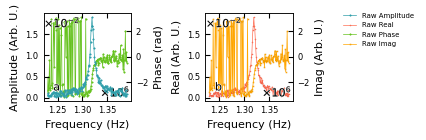

In [9]:
prediction = {"resampled": False,
              "label": "Raw"}

BE_viz.raw_data_comparison(prediction, filename="Figure_2_1_raw_cantilever_response_test")

In [10]:
BE_viz.extraction_state

In [ ]:
BE_viz.dataset

In [ ]:
BE_viz.measurement_state


In [ ]:
if np.isscalar(165) or len(165) == 1:
    print("Y")

**Figure 2.1** Raw cantilever response. a) magnitude spectrum and Phase, b) real and imaginary parts of the complex spectrum.


### Band-Excitation Experiments

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


./Figures/Figure_2_2_raw_be_experiment_test.png
./Figures/Figure_2_2_raw_be_experiment_test.svg


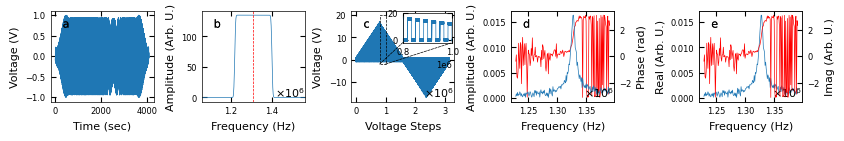

In [8]:
BE_viz.raw_be(dataset, filename="Figure_2_2_raw_be_experiment_test")

**Figure 2.2** Band-Excitation Experiments. a) raw drive amplitude applied to the tip, b) energy of the waveform in the frequency domain, c) DC voltage applied to switch the sample, inset shows a zoomed in view of the switching waveform where measurements are made in the on and off state. d) raw cantilever response magnitude and phase, e) real and imaginary parts of the complex spectrum.

## SHO Fitting
**Note**: this code takes around 15 minutes to execute

If you downloaded the SHO fit data, or ran notebook 1 you do not need to fit the data again. 

You can skip to the next section.

If you would like to run this code block please change the Fit_SHO flag to `True`

In [ ]:
Fit_SHO = False

if Fit_SHO: 

    # # computes the SHO fit for the data in the file
    dataset.SHO_Fitter(force = True)
    
    # instantiate the dataset object
    # good to reinstantiate the dataset object after fitting
    dataset = BE_Dataset(data_path)

### Views the Distribution of the Least Squares Fitting (LSQF) results

It is good to view the distributions and standardize the phase shift. The phase shift is rotated around the unit circle such that the peaks are at $-\pi/2$ and $\pi/2$

# WHY IS BE_viz.resampled_bins NONE WHEN IT SHOULD GET SET TO self.num_bins IN DATASET_NEW.PY
# or actually maybe it doesn't 

resampled_bins is now defined in State.py

num_bins is now a property of BE_Dataset

State inherits Preprocessing, which inherits BE_Dataset

Preprocessing initializes resampled_bins to self.num_bins

viz inherits State, which inherits Preprocessing, which inherits BE_Dataset



In [11]:
BE_viz.num_bins

np.int64(165)

In [8]:
dataset.resampled_bins

np.int64(165)

In [11]:
BE_viz.raw_format

'complex'

In [10]:
BE_viz.resampled_bins

In [3]:
class A:
    def __init__(self):
        print("Initializing class A")

class B(A):
    def __init__(self):
        super().__init__()
        print("Initializing class B")

class C(A):
    def __init__(self):
        super().__init__()
        print("Initializing class C")

class D(B, C):
    def __init__(self):
        super().__init__()

# Creating an instance of the D class
my_instance = D()


Initializing class A
Initializing class C
Initializing class B


In [6]:
BE_viz.SHO_preprocessing()


In [ ]:
# defining this here doesn't matter because I need to call it from BE_Viz 

preprocessor = Preprocessing()
preprocessor.SHO_preprocessing()

In [12]:
preprocessor.resampled_bins

NameError: name 'preprocessor' is not defined

In [8]:
preprocessor.SHO_LSQF_data

{'Noisy_Data_1-SHO_Fit_000': array([[[ 1.51312085e-05,  1.30957025e+06,  2.00000000e+02,
          -1.56170236e+00],
         [ 1.47375462e-05,  1.30957025e+06,  2.00000000e+02,
           1.59871711e+00],
         [ 1.50130961e-05,  1.30957025e+06,  2.00000000e+02,
          -2.47633011e+00],
         ...,
         [ 5.15541514e-05,  1.31749990e+06, -2.93124184e+02,
           2.81374016e+00],
         [ 5.74392008e-05,  1.31841712e+06, -2.38377444e+02,
          -3.03694870e+00],
         [ 6.80383629e-05,  1.31851013e+06, -2.06887458e+02,
          -3.05053158e+00]],
 
        [[ 1.56604413e-05,  1.30957025e+06,  2.00000000e+02,
           8.02450036e-01],
         [ 1.55442539e-05,  1.30957025e+06,  2.00000000e+02,
           1.19306921e+00],
         [ 1.43685168e-05,  1.30957025e+06,  2.00000000e+02,
          -2.56293411e+00],
         ...,
         [ 5.19556374e-05,  1.31970275e+06, -3.02439601e+02,
          -3.13674858e+00],
         [ 5.97664099e-05,  1.32002835e+06, -2.1454

BE_viz.SHO_fit_results() is in State.py and calls self.SHO_LSQF from State.py

self.SHO_LSQF in State.py calls SHO_LSQF_data from Preprocessing.py

Preprocessing inherits BE_Dataset 

State inherits Preprocessing 

self is Viz object because it gets called by BE_viz.SHO_fit_results() but I need it to be State object 

current_SHO_ranges: [(0, 0.00015), (1310000.0, 1330000.0), (-300, 300), (-3.141592653589793, 3.141592653589793)]
current_dataset_state: {'raw_format': 'complex', 'fitter': 'LSQF', 'scaled': False, 'output_shape': 'pixels', 'measurement_state': 'all', 'LSQF_phase_shift': 0, 'NN_phase_shift': None, 'noise': 0, 'loop_interpolated': False}


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)


./Figures/Figure_2_3_Original_LSQF_Histograms_test.png
./Figures/Figure_2_3_Original_LSQF_Histograms_test.svg


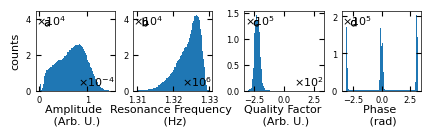

In [7]:
BE_viz.LSQF_phase_shift = 0

BE_viz.SHO_hist(BE_viz.SHO_fit_results(),
                      filename="Figure_2_3_Original_LSQF_Histograms_test")


**Figure 2.3** Distribution of the Least Squares Fitting (LSQF) results of the unmodified data. a) Distribution of the amplitude, b) Distribution of the resonance frequency, c) distribution of the quality factor, d) distribution of the resonance frequency.

In [10]:
from dataclasses import field
from typing import List, Dict, Optional, Type


In [12]:
SHO_labels: Optional[List[Dict[str, str]]]= field(
    default_factory=lambda: [
        {"title": "Amplitude", "y_label": "Amplitude \n (Arb. U.)"},
        {"title": "Resonance Frequency", "y_label": "Resonance Frequency \n (Hz)"},
        {"title": "Dampening", "y_label": "Quality Factor \n (Arb. U.)"},
        {"title": "Phase", "y_label": "Phase \n (rad)"},
    ]
)
                 

In [14]:
for label in SHO_labels:
    print(label)

TypeError: 'Field' object is not iterable

current_SHO_ranges: [(0, 0.00015), (1310000.0, 1330000.0), (-300, 300), (-3.141592653589793, 3.141592653589793)]
current_dataset_state: {'raw_format': 'complex', 'fitter': 'LSQF', 'scaled': False, 'output_shape': 'pixels', 'measurement_state': 'all', 'LSQF_phase_shift': 1.5707963267948966, 'NN_phase_shift': None, 'noise': 0, 'loop_interpolated': False}


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)


./Figures/Figure_4_Phase_Shifted_LSQF_Histograms_test.png
./Figures/Figure_4_Phase_Shifted_LSQF_Histograms_test.svg


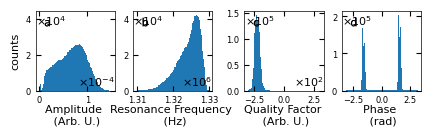

In [9]:
BE_viz.LSQF_phase_shift = np.pi/2

BE_viz.SHO_hist(BE_viz.SHO_fit_results(),
                      filename="Figure_4_Phase_Shifted_LSQF_Histograms_test")

**Figure 2.4** Distribution of the Least Squares Fitting (LSQF) results of the normalized data. a) Distribution of the amplitude, b) distribution of the resonance frequency, c) distribution of the quality factor, d) distribution of the resonance frequency.

### Plots the SHO Fit Results

In [10]:
BE_viz.dataset.measurement_state = 'on'

BE_viz.SHO_loops(filename="Figure_2_5_Single_Pixel_Loops_test")

AttributeError: 'Viz' object has no attribute 'SHO_loops'

**Figure 2_5.** Example switching loops obtained for the amplitude, resonance frequency, quality factor, and phase.

## SHO Switching Movies

In [ ]:
BE_viz.SHO_fit_movie_images(noise = 0, 
                            scalebar_= True, 
                            basepath = "Movies/SHO_LSQF_",  
                            filename="SHO_LSQF",
                            phase_shift = [np.pi/2])